<a href="https://colab.research.google.com/github/darealDot/ProjectShowcase/blob/main/phishing_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

by "darealDot" on GitHub

https://github.com/darealDot

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sb

import numpy as np
import pandas as pd

pd.options.display.max_columns = 200

# https://github.com/facebook/prophet/issues/999
pd.plotting.register_matplotlib_converters()
from scipy.stats import ttest_ind # t-test
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#Reading in the data

In [ ]:
phishingDF = pd.read_csv("https://raw.githubusercontent.com/darealDot/random-CSV/refs/heads/main/verified_online.csv")

In [ ]:
phishingDF.shape

(47974, 8)

In [ ]:
phishingDF.head()

,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,9280868,https://inpost-pl.stealizk.click/payment/e1949...,http://www.phishtank.com/phish_detail.php?phis...,2025-12-01T15:48:26+00:00,yes,2025-12-01T16:12:08+00:00,yes,Other
1,9280862,https://moja-paczka.cereols.click/payment/e194...,http://www.phishtank.com/phish_detail.php?phis...,2025-12-01T15:46:26+00:00,yes,2025-12-01T15:52:02+00:00,yes,Other
2,9280860,https://moja-paczka.tormino.click/payment/e194...,http://www.phishtank.com/phish_detail.php?phis...,2025-12-01T15:44:26+00:00,yes,2025-12-01T15:52:02+00:00,yes,Other
3,9280859,https://moja-paczka.dertram.click/payment/e194...,http://www.phishtank.com/phish_detail.php?phis...,2025-12-01T15:42:26+00:00,yes,2025-12-01T15:52:02+00:00,yes,Other
4,9280857,https://moja-paczka.deniva.click/payment/e1949...,http://www.phishtank.com/phish_detail.php?phis...,2025-12-01T15:40:26+00:00,yes,2025-12-01T15:52:02+00:00,yes,Other


In [ ]:
phishingDF.tail()

,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
47969,4173961,http://webmailadmin0.myfreesites.net/,http://www.phishtank.com/phish_detail.php?phis...,2016-06-13T00:17:16+00:00,yes,2016-11-18T03:03:26+00:00,yes,Other
47970,2042606,http://www.formbuddy.com/cgi-bin/formdisp.pl?u...,http://www.phishtank.com/phish_detail.php?phis...,2013-09-30T13:24:39+00:00,yes,2013-10-01T13:33:17+00:00,yes,Other
47971,1865971,http://www.formbuddy.com/cgi-bin/formdisp.pl?u...,http://www.phishtank.com/phish_detail.php?phis...,2013-05-28T15:59:31+00:00,yes,2013-05-28T22:13:12+00:00,yes,Other
47972,1460953,http://www.habbocreditosparati.blogspot.com/,http://www.phishtank.com/phish_detail.php?phis...,2012-06-14T15:19:26+00:00,yes,2012-06-14T15:29:11+00:00,yes,Sulake Corporation
47973,1123978,http://creditiperhabbogratissicuro100.blogspot...,http://www.phishtank.com/phish_detail.php?phis...,2011-02-18T10:50:32+00:00,yes,2011-02-19T00:05:43+00:00,yes,Sulake Corporation


Checking the N's by making sure phishing ID's are unique and every attack is verified to be true

In [ ]:
phishingDF['phish_id'].value_counts().sum()

np.int64(47974)

In [ ]:
phishingDF['verified'].value_counts()

,count
verified,
yes,47974


In [ ]:
phishingCopy = phishingDF.copy()
phishingCopy['submission_time'] = pd.to_datetime(phishingCopy['submission_time'])
phishingCopy.head()

,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,9280868,https://inpost-pl.stealizk.click/payment/e1949...,http://www.phishtank.com/phish_detail.php?phis...,2025-12-01 15:48:26+00:00,yes,2025-12-01T16:12:08+00:00,yes,Other
1,9280862,https://moja-paczka.cereols.click/payment/e194...,http://www.phishtank.com/phish_detail.php?phis...,2025-12-01 15:46:26+00:00,yes,2025-12-01T15:52:02+00:00,yes,Other
2,9280860,https://moja-paczka.tormino.click/payment/e194...,http://www.phishtank.com/phish_detail.php?phis...,2025-12-01 15:44:26+00:00,yes,2025-12-01T15:52:02+00:00,yes,Other
3,9280859,https://moja-paczka.dertram.click/payment/e194...,http://www.phishtank.com/phish_detail.php?phis...,2025-12-01 15:42:26+00:00,yes,2025-12-01T15:52:02+00:00,yes,Other
4,9280857,https://moja-paczka.deniva.click/payment/e1949...,http://www.phishtank.com/phish_detail.php?phis...,2025-12-01 15:40:26+00:00,yes,2025-12-01T15:52:02+00:00,yes,Other


#getting the monthly data and looking at the head and tail

In [ ]:
#
phishingCopy['submission_time'] = pd.to_datetime(phishingCopy['submission_time'], utc=True, errors='coerce')

# making the verified a bool
phishingCopy['is_verified'] = phishingCopy['verified'].astype(str).str.lower().eq('yes')

# making the month colmn in the frame
phishingCopy['month'] = phishingCopy['submission_time'].dt.to_period('M')

# grouping by month
monthlyCounts = phishingCopy.groupby('month')['is_verified'].sum().astype(int)

monthlyPhishing = monthlyCounts.to_frame(name='verified_count').reset_index()
monthlyPhishing['month'] = monthlyPhishing['month'].dt.strftime('%Y-%m')
monthlyPhishing.head()

/tmp/ipython-input-2010012134.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  phishingCopy['month'] = phishingCopy['submission_time'].dt.to_period('M')


,month,verified_count
0,2011-02,1
1,2012-06,1
2,2013-05,1
3,2013-09,1
4,2016-06,1


In [ ]:
monthlyPhishing.tail()

,month,verified_count
97,2025-08,2153
98,2025-09,1801
99,2025-10,2408
100,2025-11,5357
101,2025-12,221


#plotting the total phishing attacks over time

<Figure size 1000x500 with 0 Axes>

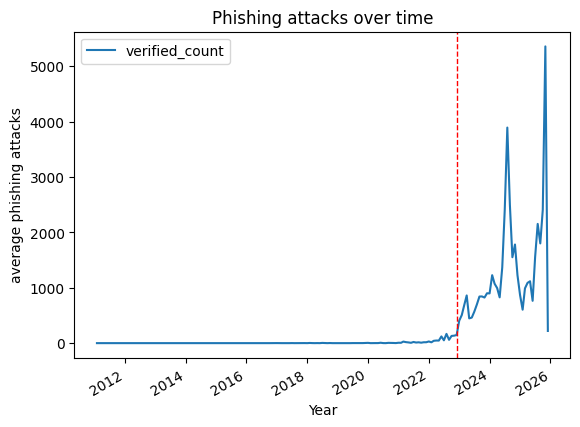

In [ ]:
#Setting up the plotting enviornm
phishingGraph = monthlyPhishing.copy() #made a copy because there was an error when re-running code
phishingGraph['month'] = pd.to_datetime(phishingGraph['month'])
phishingGraph = phishingGraph.set_index('month')


# Plot settings
plt.figure(figsize=(10, 5))
phishingGraph.plot()
#red line plotted to show the release date of ChatGPT Ai model
plt.axvline(pd.to_datetime("2022-11-30"), color='red', linestyle='--', linewidth=1)
plt.xlabel("Year")
plt.ylabel("average phishing attacks")
plt.title("Phishing attacks over time")
plt.show()

splitting the dataframe into two:

In [ ]:
phishingGraph.index = pd.to_datetime(phishingGraph.index)
#making the dates to split the dataframe
startDate1 = "2021-01-01"
endDate1 = "2022-11-30"
startDate2 = "2022-12-01"
endDate2 = "2025-11-30"
phishingBeforeAI = phishingGraph.loc[startDate1 : endDate1]
phishingAfterAI = phishingGraph.loc[startDate2 : endDate2]
#making a new dataset of just the data I want to look at for regression. 2021-2025
phishingData = phishingGraph.loc[startDate1 : endDate2]

Looking at the heads and tails of both DF to make sure the time is set correctly

In [ ]:
phishingBeforeAI.head()

,verified_count
month,
2021-01-01,8
2021-02-01,7
2021-03-01,29
2021-04-01,19
2021-05-01,14


In [ ]:
phishingBeforeAI.tail()

,verified_count
month,
2022-07-01,52
2022-08-01,168
2022-09-01,61
2022-10-01,131
2022-11-01,136


In [ ]:
phishingAfterAI.head()

,verified_count
month,
2022-12-01,147
2023-01-01,406
2023-02-01,508
2023-03-01,679
2023-04-01,862


In [ ]:
phishingAfterAI.tail()

,verified_count
month,
2025-07-01,1555
2025-08-01,2153
2025-09-01,1801
2025-10-01,2408
2025-11-01,5357


Running A T Test to compare if the increase of phishing attacks after chatGPT release is statistically significant.

In [ ]:
t_score, p_value = ttest_ind(phishingBeforeAI, phishingAfterAI)
print('T Score: {}'.format(t_score))
print('P value: {}'.format(p_value))

T Score: [-5.84920707]
P value: [2.53683588e-07]


Plotting with the desired timeframe

<Figure size 1000x500 with 0 Axes>

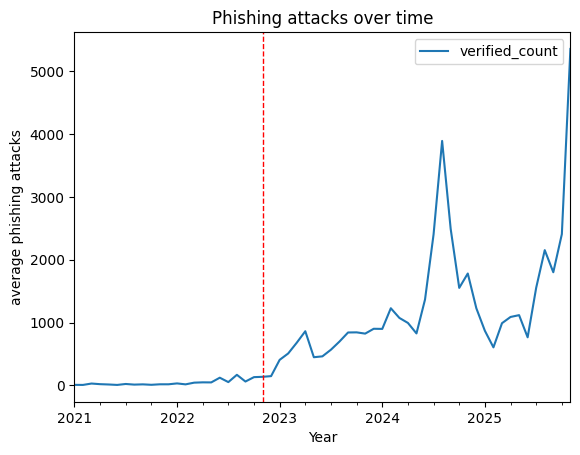

In [ ]:
plt.figure(figsize=(10, 5))
phishingData.plot()
#red line plotted to show the release date of ChatGPT Ai model
plt.axvline(pd.to_datetime("2022-11-30"), color='red', linestyle='--', linewidth=1)
plt.xlabel("Year")
plt.ylabel("average phishing attacks")
plt.title("Phishing attacks over time")
plt.show()

Plotting the rolling mean

<Figure size 1000x500 with 0 Axes>

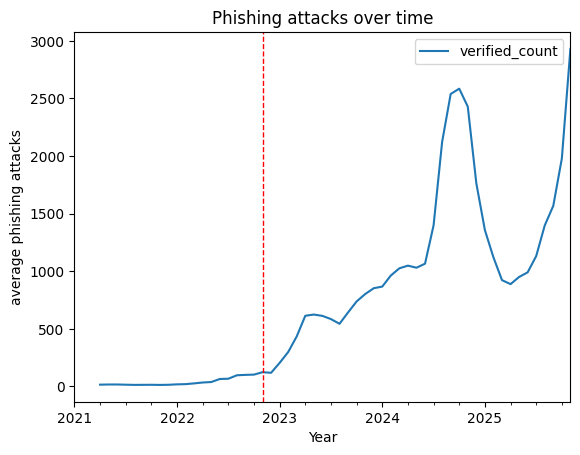

In [ ]:
rolling_mean = phishingData.rolling(window=4).mean()
plt.figure(figsize=(10, 5))
rolling_mean.plot()
#red line plotted to show the release date of ChatGPT Ai model
plt.axvline(pd.to_datetime("2022-11-30"), color='red', linestyle='--', linewidth=1)
plt.xlabel("Year")
plt.ylabel("average phishing attacks")
plt.title("Phishing attacks over time")
plt.show()

Checking the autocorrelation

In [ ]:
monthlyPhishingAutoCorr = phishingData.copy() #will be used for forecasting later
phishingAutoCorr = phishingData.copy()
phishingAutoCorr['shift1'] = phishingAutoCorr['verified_count'].shift(1)
phishingAutoCorr['shift2'] = phishingAutoCorr['verified_count'].shift(2)
phishingAutoCorr['shift3'] = phishingAutoCorr['verified_count'].shift(3)
phishingAutoCorr['shift4'] = phishingAutoCorr['verified_count'].shift(4)
phishingAutoCorr.head()


,verified_count,shift1,shift2,shift3,shift4
month,,,,,
2021-01-01,8,NaN,NaN,NaN,NaN
2021-02-01,7,8.0,NaN,NaN,NaN
2021-03-01,29,7.0,8.0,NaN,NaN
2021-04-01,19,29.0,7.0,8.0,NaN
2021-05-01,14,19.0,29.0,7.0,8.0


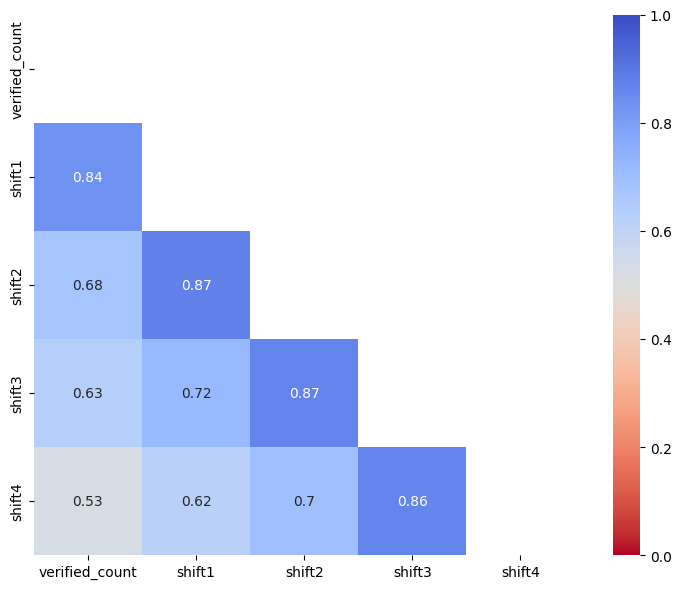

In [ ]:
phishingCorr = phishingAutoCorr[['verified_count','shift1','shift2','shift3','shift4']].corr()

# Using masking code from: https://seaborn.pydata.org/generated/seaborn.heatmap.html
phishMask = np.zeros_like(phishingCorr)
phishMask[np.triu_indices_from(phishMask)] = True

# Set up the plotting environment
f,ax = plt.subplots(1,1,figsize=(8,6))

# Make a heatmap
sb.heatmap(phishingCorr,vmin=0,vmax=1,mask=phishMask,annot=True,square=True,ax=ax,cmap='coolwarm_r')

f.tight_layout()

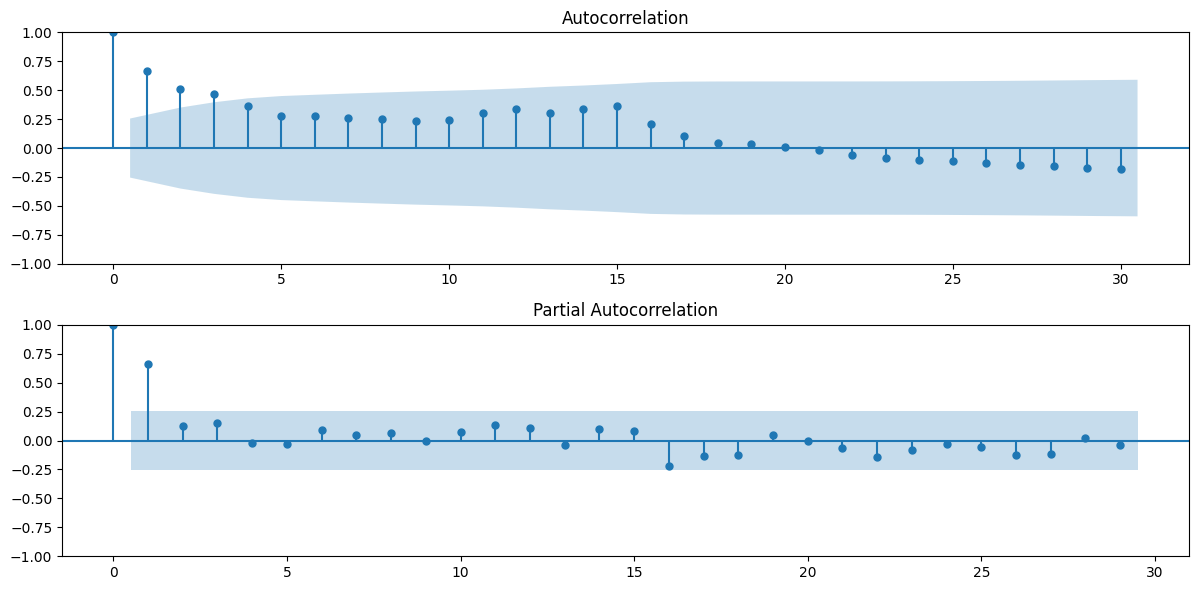

In [ ]:
# Create the figure
plt.figure(figsize=(12, 6))


plt.subplot(2, 1, 1)
plot_acf(monthlyPhishingAutoCorr, ax=plt.gca(), lags=30)
plt.title("Autocorrelation")


plt.subplot(2, 1, 2)
plot_pacf(monthlyPhishingAutoCorr, ax=plt.gca(), lags=29, method='ywm')
plt.title("Partial Autocorrelation")

plt.tight_layout()
plt.show()


Forecasting future phishing attacks

In [ ]:
!python -m pip install prophet==1.2.1

In [ ]:
from prophet import Prophet

In [ ]:
prophet_phishing = phishingData.copy()
prophet_phishing = prophet_phishing.reset_index().rename(columns={"month": "ds", "verified_count": "y"})
prophet_phishing.head()

,ds,y
0,2021-01-01,8
1,2021-02-01,7
2,2021-03-01,29
3,2021-04-01,19
4,2021-05-01,14


In [ ]:
m3 = Prophet(weekly_seasonality=False,daily_seasonality=False).fit(prophet_phishing)

In [ ]:
m3_future = m3.make_future_dataframe(periods=120,freq='ME')

#inspecting the tail to make sure its monthly
m3_future.tail()

,ds
174,2035-06-30
175,2035-07-31
176,2035-08-31
177,2035-09-30
178,2035-10-31


In [ ]:
m3_forecast = m3.predict(m3_future)

#looking at the returned columns
m3_forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
174,2035-06-30,6517.602357,5822.147902,7267.473147
175,2035-07-31,5294.990202,4506.096525,6034.566466
176,2035-08-31,7655.735869,6935.427914,8465.810546
177,2035-09-30,8319.476487,7616.472531,9060.982949
178,2035-10-31,6538.632897,5765.776841,7241.424491


Text(0.5, 1.0, 'Observation and Forecast of Phishing Attacks')

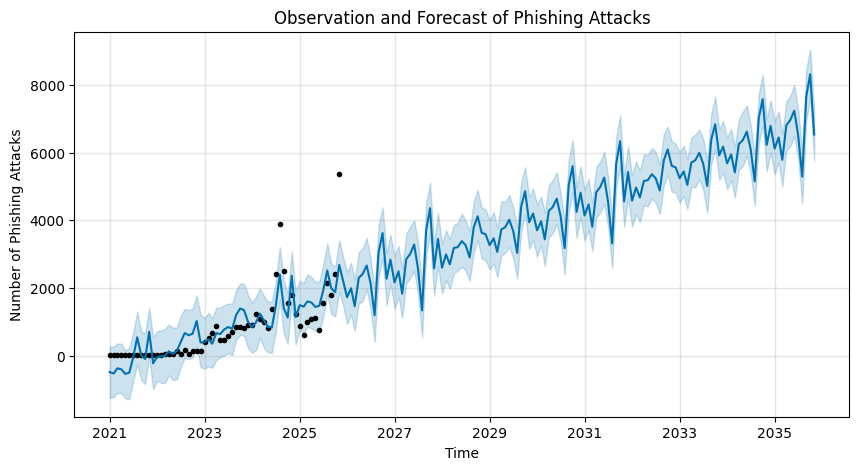

In [ ]:
f,ax = plt.subplots(1,1,figsize=(10,5))
_ = m3.plot(m3_forecast,ax=ax)

#labling the graph
ax.set_xlabel('Time')
ax.set_ylabel('Number of Phishing Attacks')
ax.set_title('Observation and Forecast of Phishing Attacks')